# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

*NOTE:WHEN I TRY TO INCREASE THE IMAGE SIZE THEN MY SYSTEM CRASHES, WHICH I ATTEMPTED AS AMETHOD TO MPROVE MY ACCURACY. SO I KEPT THE IMAGE SIZE 128 X 128*

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import os
import random

Load the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Defining the path to your zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/data.zip'  # update if your path differs
extraction_path = '/content/waste_data'

import os
os.makedirs(extraction_path, exist_ok=True)

# -o = overwrite existing files without prompting, -q = quiet (less clutter)
!unzip -q -o "{zip_file_path}" -d "{extraction_path}"

print("Unzip complete.")

Unzip complete.


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [ ]:
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    try:
        img = Image.open(image_path)
        img = img.convert('RGB')     # Ensuring image is in RGB format
        img = img.resize(target_size) # Resizing the image to target_size
        return np.array(img)
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

print("load_and_preprocess_image function defined.")

load_and_preprocess_image function defined.


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [ ]:
data_dir = os.path.join(extraction_path, 'data')
images = []
labels = []

# Looping through each subdirectory (which represents a class/label)
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            # Loading and preprocessing the image using the defined function
            img = load_and_preprocess_image(image_path)
            if img is not None:
                images.append(img)
                labels.append(class_name)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Total labels loaded: {len(labels)}")
print(f"Unique labels: {np.unique(labels)}")
print(f"Shape of images array: {images.shape}")

Total images loaded: 7625
Total labels loaded: 7625
Unique labels: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
Shape of images array: (7625, 128, 128, 3)


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

/tmp/ipykernel_1614/1223538247.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


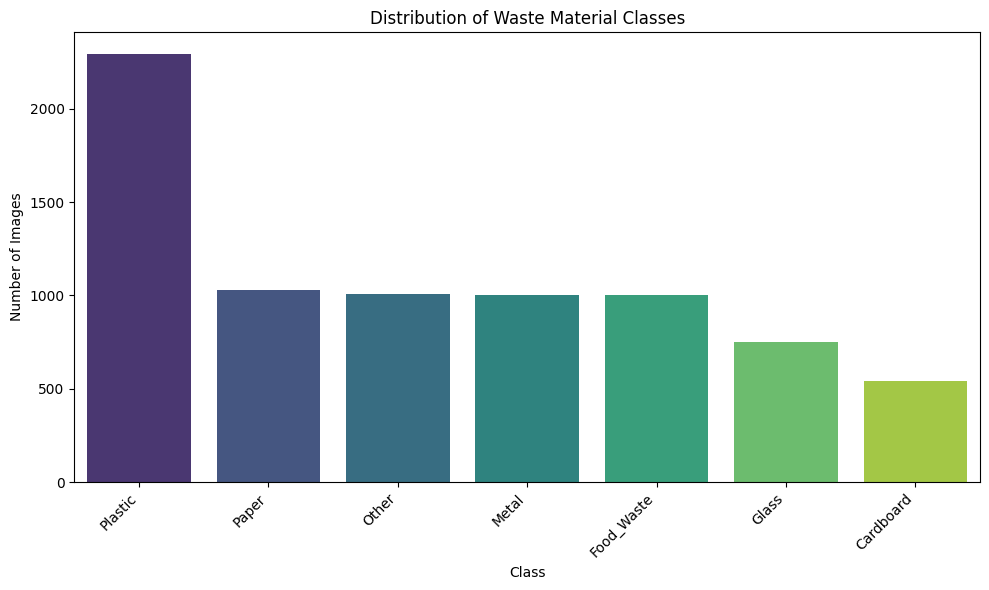

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class distribution
class_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Waste Material Classes')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

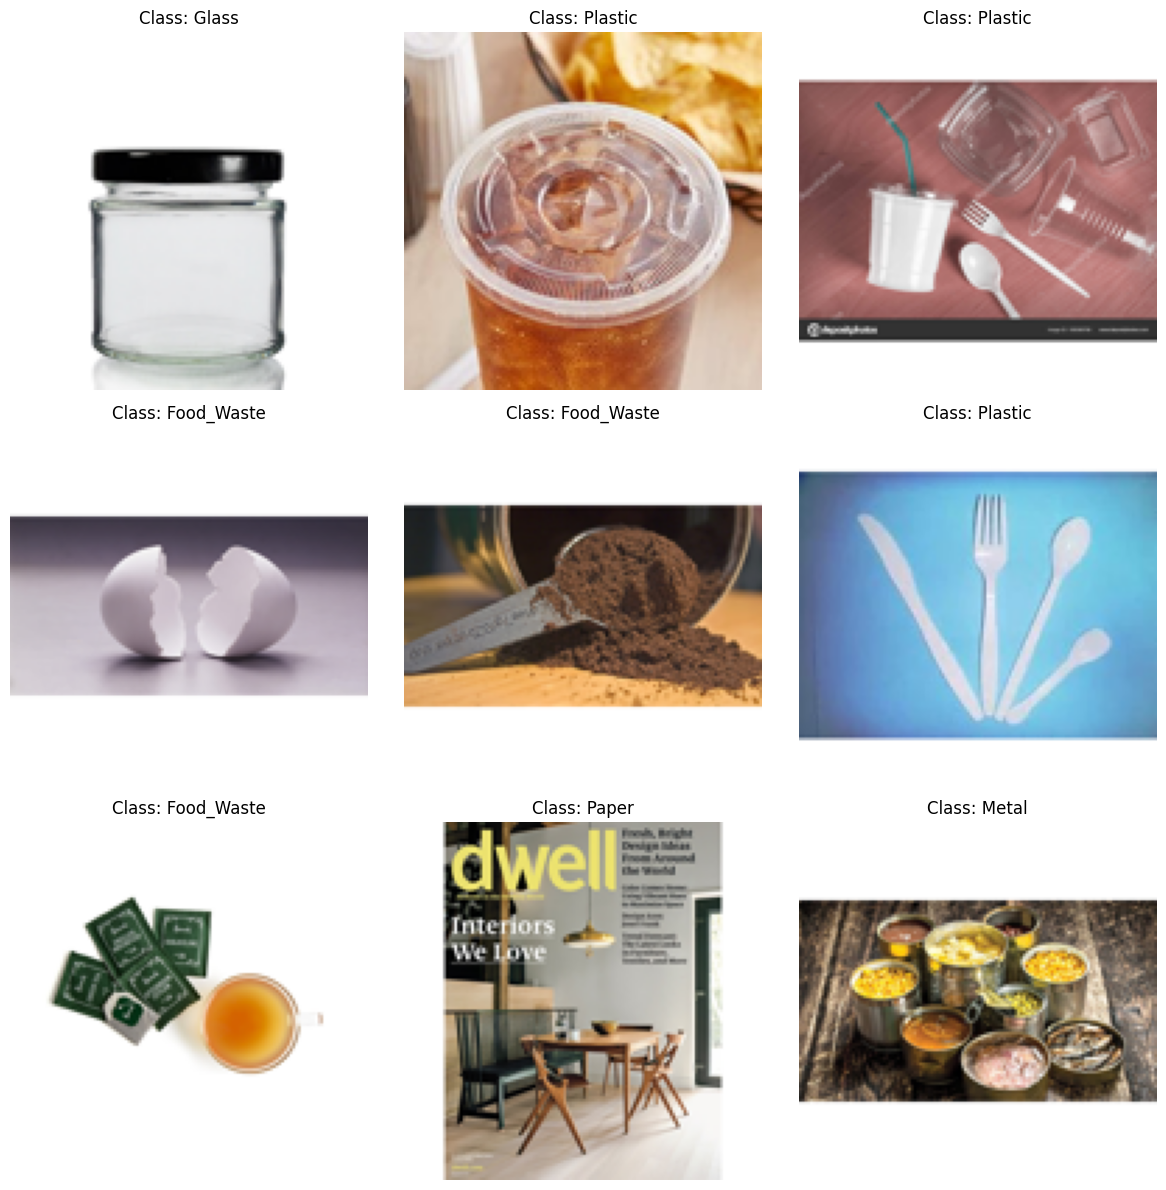

In [ ]:
plt.figure(figsize=(12, 12))
num_samples = 9 # We are setting number of sample images to display

# Getting unique labels
unique_labels = np.unique(labels)

for i in range(num_samples):
    plt.subplot(3, 3, i + 1)

    # Picking a random image from the dataset
    rand_idx = random.randint(0, len(images) - 1)
    plt.imshow(images[rand_idx])
    plt.title(f"Class: {labels[rand_idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [ ]:
min_dim = float('inf')
max_dim = 0

for img_array in images:
    height, width, _ = img_array.shape
    min_dim = min(min_dim, min(height, width))
    max_dim = max(max_dim, max(height, width))

print(f"Smallest image dimension: {min_dim}x{min_dim}")
print(f"Largest image dimension: {max_dim}x{max_dim}")

Smallest image dimension: 128x128
Largest image dimension: 128x128


In [ ]:
new_target_size = (128, 128)

resized_images = []
for img_array in images:
    # Converting numpy array back to PIL Image for resizing
    img_pil = Image.fromarray(img_array)
    img_resized = img_pil.resize(new_target_size)
    resized_images.append(np.array(img_resized))

images = np.array(resized_images)
print(f"All images resized to: {images.shape[1]}x{images.shape[2]}")

All images resized to: 128x128


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initializing LabelEncoder
label_encoder = LabelEncoder()

# Fitting and transforming the labels
encoded_labels = label_encoder.fit_transform(labels)

print("Original Labels (first 5):")
print(labels[:5])
print("\nEncoded Labels (first 5):")
print(encoded_labels[:5])
print("\nUnique Original Labels:")
print(label_encoder.classes_)
print("\nUnique Encoded Labels:")
print(np.unique(encoded_labels))

Original Labels (first 5):
['Cardboard' 'Cardboard' 'Cardboard' 'Cardboard' 'Cardboard']

Encoded Labels (first 5):
[0 0 0 0 0]

Unique Original Labels:
['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']

Unique Encoded Labels:
[0 1 2 3 4 5 6]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [ ]:
from sklearn.model_selection import train_test_split

# Normalize image data to a range of 0 to 1
images_normalized = images.astype('float32') / 255.0

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    images_normalized, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (6100, 128, 128, 3)
Shape of y_train: (6100,)
Shape of X_val: (1525, 128, 128, 3)
Shape of y_val: (1525,)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

# Getting the number of classes from the unique encoded labels
num_classes = len(np.unique(encoded_labels))

# Defining the input shape (image height, image width, channels)
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with number of classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,831 (32.37 MB)

 Trainable params: 8,484,871 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.3305 - loss: 2.0413 - val_accuracy: 0.1298 - val_loss: 8.7002
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3989 - loss: 1.6938 - val_accuracy: 0.1954 - val_loss: 10.0842
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4669 - loss: 1.4766 - val_accuracy: 0.3226 - val_loss: 6.7955
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4890 - loss: 1.4287 - val_accuracy: 0.3882 - val_loss: 1.7100
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5195 - loss: 1.3232 - val_accuracy: 0.3895 - val_loss: 1.8946
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5611 - loss: 1.2265 - val_accuracy: 0.4413 - val_loss: 1.6001
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6059 - loss: 1.1100 - val_accuracy: 0.3941 - val_loss: 2.1536
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6120 - loss: 1.0651 - val_ac

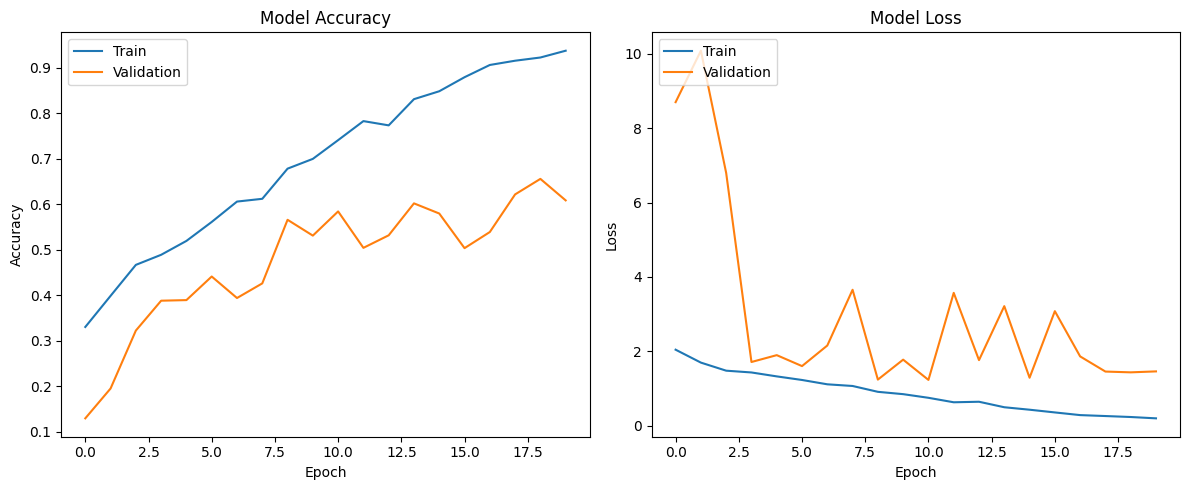

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20, # We train for 20 epochs
    batch_size=32, # We se a batch size of 32
    validation_data=(X_val, y_val)
)

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Validation Loss: 1.4575
Validation Accuracy: 0.6085
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.81      0.67      0.73       108
  Food_Waste       0.55      0.76      0.63       200
       Glass       0.59      0.55      0.57       150
       Metal       0.89      0.41      0.57       200
       Other       0.53      0.38      0.44       202
       Paper       0.71      0.45      0.55       206
     Plastic       0.57      0.81      0.67       459

    accuracy                           0.61      1525
   macro avg       0.66      0.57      0.59      1525
weighted avg       0.64      0.61      0.60      1525



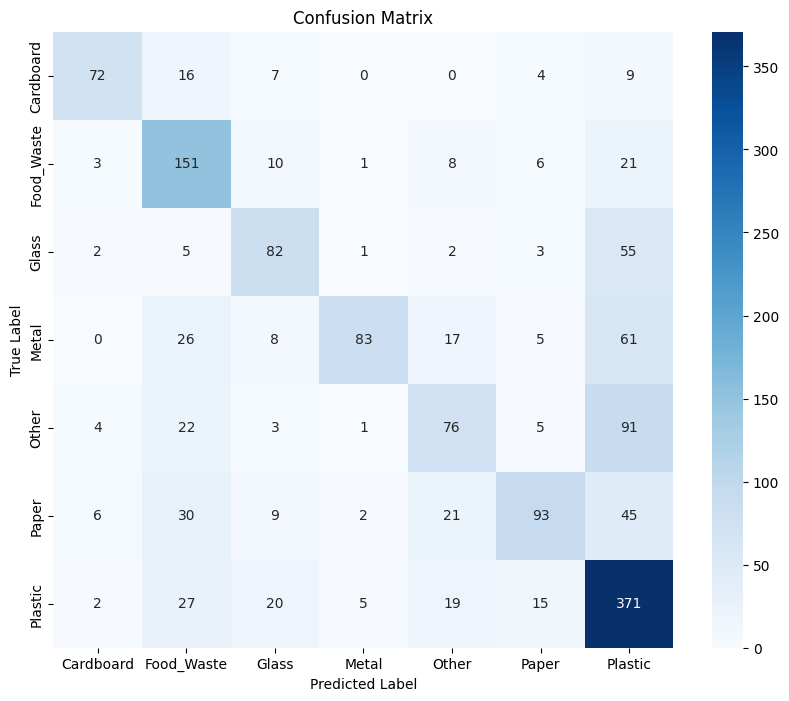

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Predicting classes for the validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generating classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# Generating confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
import tensorflow as tf

# Defining augmentation steps to augment images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128, 128, 3)), # Explicitly define input shape to accept images with batch dim
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(factor=0.2),
])

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images
def augment_data(image, label):
    # Applying the data_augmentation pipeline to the image
    image = data_augmentation(image, training=True)
    return image, label

print("Augment data function defined.")

Augment data function defined.


In [ ]:
import tensorflow as tf


# Converting numpy arrays to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Applying augmentation to the training dataset
# The .map() function expects a TensorFlow function, so we define the augmentation steps
# directly within the lambda, ensuring batch dimension handling.
augmented_train_dataset = train_dataset.map(
    lambda image, label: (
        tf.squeeze(data_augmentation(tf.expand_dims(image, axis=0), training=True), axis=0),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Further preparing the dataset for training
# Shuffle and batch the augmented data
BATCH_SIZE = 32 # Use the same batch size as model training
augmented_train_dataset = augmented_train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Also create a validation dataset (without augmentation)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Augmented training dataset and validation dataset created.")

Augmented training dataset and validation dataset created.


##### **4.1.2**

Train the model on the new augmented dataset.

Starting model training with augmented data...
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 50s 190ms/step - accuracy: 0.2143 - loss: 2.5761 - val_accuracy: 0.3016 - val_loss: 2.0244
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 139ms/step - accuracy: 0.2148 - loss: 2.2819 - val_accuracy: 0.1449 - val_loss: 1.9965
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 134ms/step - accuracy: 0.2267 - loss: 2.1309 - val_accuracy: 0.3016 - val_loss: 1.8399
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 42s 136ms/step - accuracy: 0.2344 - loss: 2.0577 - val_accuracy: 0.2820 - val_loss: 1.8913
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 139ms/step - accuracy: 0.2433 - loss: 1.9925 - val_accuracy: 0.3010 - val_loss: 1.8631
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 138ms/step - accuracy: 0.2633 - loss: 1.9522 - val_accuracy: 0.1351 - val_loss: 2.8408
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 30s 138ms/step - accuracy: 0.2697 - loss: 1.9248 - val_accuracy: 0.3010 - val_loss: 1.8483
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━

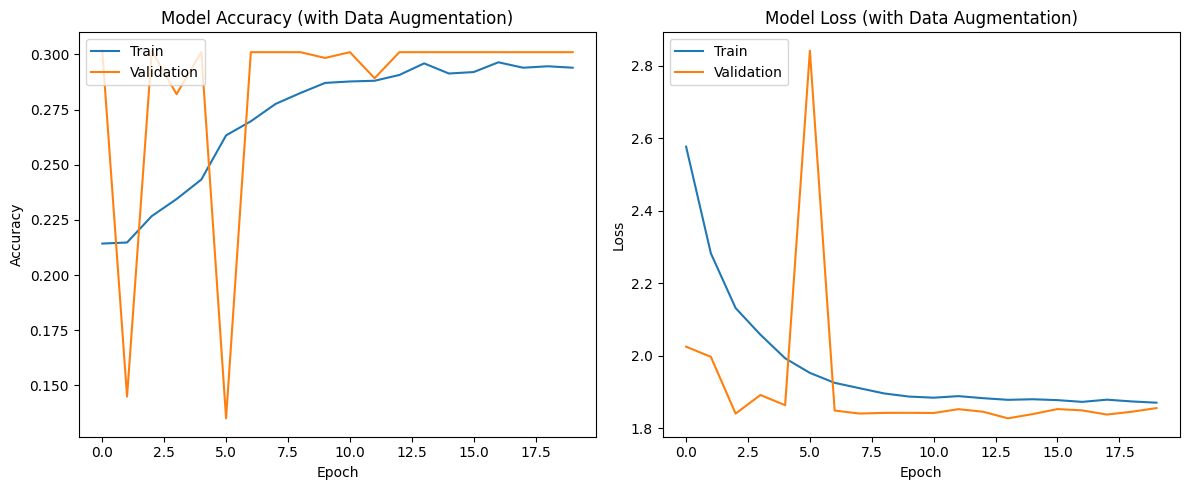

In [ ]:
# Train the model using augmented images

# Re-instantiate the model to reset its weights, as we are training it again
# This assumes the 'model' object was defined in a previous cell and we want to retrain it.
# If the model structure is different for augmented training, it should be redefined.
# For now, let's assume we use the same model architecture.
model_augmented = tf.keras.models.clone_model(model)
model_augmented.set_weights(model.get_weights()) # Optionally start with previous weights

# Compile the new model instance (or re-compile if using the same instance)
model_augmented.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

print("Starting model training with augmented data...")
history_augmented = model_augmented.fit(
    augmented_train_dataset, # Use the augmented dataset
    epochs=20,               # Using the same number of epochs as before
    validation_data=val_dataset, # Use the prepared validation dataset
    verbose=1
)

print("Model training with augmented data completed.")

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_augmented.history['accuracy'])
plt.plot(history_augmented.history['val_accuracy'])
plt.title('Model Accuracy (with Data Augmentation)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_augmented.history['loss'])
plt.plot(history_augmented.history['val_loss'])
plt.title('Model Loss (with Data Augmentation)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

### **Data Findings and Preparation:**

*   **Dataset Overview:** The dataset consists of 7625 images categorized into 7 distinct waste material classes: 'Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', and 'Plastic'.

*   **Image Characteristics:** All images were loaded and preprocessed to a consistent size of 128x128 pixels, and normalized to a range of 0 to 1 for model input.

*   **Class Distribution:** The dataset exhibits class imbalance, with 'Plastic' being the majority class (2295 images) and 'Cardboard' being the minority class (540 images). This imbalance could affect model performance, particularly for underrepresented classes.

*   **Data Split:** The dataset was split into an 80% training set (6100 images) and a 20% validation set (1525 images) using a stratified sampling approach to maintain class proportions in both sets.

### **Model Training Results:**

#### **1. Original Model Training:**

*   **Architecture:** A Convolutional Neural Network (CNN) with three convolutional blocks, each followed by Batch Normalization, MaxPooling, and Dropout layers, culminating in fully connected layers and a softmax output layer.

*   **Performance:** After 20 epochs, the model achieved a **training accuracy of approximately 0.9372** and a **validation accuracy of approximately 0.6085**.

*   **Observations:** The significant gap between training and validation accuracy suggests that the model might be overfitting to the training data. The validation loss was approximately 1.4575.

*   **Class-wise Performance:** The classification report indicated varying performance across classes. For instance, 'Plastic' showed a relatively high recall (0.81), while 'Metal' and 'Other' had lower recall values (0.41 and 0.38, respectively), highlighting the model's struggle with certain categories, potentially due to class imbalance or inter-class similarities.

#### **2. Augmented Model Training:**

*   **Augmentation Strategy:** A data augmentation pipeline was applied to the training dataset using `RandomFlip`, `RandomRotation`, `RandomZoom`, and `RandomBrightness` transformations. Each image was expanded with a batch dimension, augmented, and then squeezed back to its original shape.

*   **Performance:** Surprisingly, training with the augmented dataset resulted in a significant drop in performance. The **training accuracy was approximately 0.2939**, and the **validation accuracy was around 0.3010** after 20 epochs.

*   **Observations:** Both training and validation accuracies were very low, close to random guessing for 7 classes (1/7 = ~0.14). The validation loss was higher, around 1.8552. This suggests that the chosen augmentation techniques, or their parameters, might have been too aggressive, distorting the images to an extent that made learning difficult for the model, or the model might have lost its initial learned weights completely during re-instantiation without proper fine-tuning.